# 🛡️ Fashion Insta — Gestion des Risques Projet IA
## Roadmap complet : Description → Identification → Priorisation → Prévention → Suivi

---

> **Projet** : Application mobile de recommandation vestimentaire par photos  
> **Contexte** : Mission 3 — Anticipation des risques RGPD & projet IA  
> **Auteur** : Rafael CEREZO MARTIN — Avril 2026

```
ROADMAP SUIVI DANS CE NOTEBOOK
═══════════════════════════════════════════════════════════════
 ① DESCRIPTION DU PROJET       →  QQOQCCP + Périmètre + SWOT
 ② IDENTIFICATION DES RISQUES  →  Grille 7D + Inventaire
 ③ PRIORISATION                →  Matrice Criticité P×G + AMDEC
 ④ PLAN DE PRÉVENTION          →  Tableau parades + responsables
 ⑤ SUIVI CONTINU               →  Radar de risques + reporting
═══════════════════════════════════════════════════════════════
```

In [2]:
# ── Setup global ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Palette Fashion Insta
GOLD     = '#7D6608';  GOLD_DK  = '#5C4D06'
WHITE    = '#FFFFFF';  BG       = '#FAFAF8'
RED      = '#C0392B';  RED_L    = '#FADBD8'
ORANGE   = '#E67E22';  ORANGE_L = '#FAE5D3'
YELLOW   = '#D4AC0D';  YELLOW_L = '#FEF9E7'
GREEN    = '#27AE60';  GREEN_L  = '#D5F5E3'
BLUE     = '#2980B9';  BLUE_L   = '#D6EAF8'
GRAY     = '#5D6D7E'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': WHITE,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

def section_header(title, emoji='📌', color=GOLD_DK):
    display(HTML(f"""
    <div style='background:{color};color:white;padding:12px 18px;border-radius:6px;
                font-size:15px;font-weight:bold;margin:18px 0 8px 0;'>
        {emoji}&nbsp; {title}
    </div>"""))

def info_box(text, color=BLUE_L, border=BLUE):
    display(HTML(f"""
    <div style='background:{color};border-left:5px solid {border};padding:10px 14px;
                border-radius:4px;margin:6px 0;font-size:13px;'>{text}</div>"""))

    
print('✅ Setup OK — Gestion des Risques Fashion Insta IA')
print('   Suivez les sections dans l\'ordre du roadmap 👇')

✅ Setup OK — Gestion des Risques Fashion Insta IA
   Suivez les sections dans l'ordre du roadmap 👇


---
# 📋 ÉTAPE ① — DESCRIPTION DU PROJET
> *Établir le contexte et la compréhension totale avant d'analyser les risques*

## DOC: QQOQCCP 

In [3]:
section_header('QQOQCCP — Description systématique du projet Fashion Insta IA', '🎯')

qqoqccp = pd.DataFrame([
    ('Qui ?',    'Fashion Insta (client), équipe Data interne (7 profils), Microsoft Azure (partenaire technique)'),
    ('Quoi ?',   'Application mobile IA de recommandation vestimentaire par analyse de photos de garde-robe'),
    ('Où ?',     '11 magasins physiques + site e-commerce + app mobile iOS/Android. Infra : Azure EU (Data Residency)'),
    ('Quand ?',  'Développement : 18 semaines (S1→S18). Lancement prod : M6. Horizon ROI : 24 mois'),
    ('Comment ?','Computer Vision + ML Embedding + GPT-4V (Azure OpenAI). Pipeline MLOps Azure. 400K users cibles'),
    ('Combien ?','Budget CAPEX : ~184 690 €. OPEX mensuel : 9 350–15 100 €/mois. ROI break-even : Mois 11'),
    ('Pourquoi ?','Augmenter CA Web +14% et CA Magasin +4% via expérience personnalisée et réduction friction achat'),
])
qqoqccp.columns = ['Dimension', 'Réponse']

display(qqoqccp.style
    .set_table_styles([{'selector': 'th', 'props': [('background-color', GOLD_DK), ('color','white'), ('font-weight','bold'), ('font-size','13px')]},
                       {'selector': 'td', 'props': [('font-size','12px'), ('padding','8px 12px')]}])
    .set_properties(subset=['Dimension'], **{'font-weight':'bold', 'color': GOLD_DK, 'background-color': BG})
    .hide(axis='index')
)

Dimension,Réponse
Qui ?,"Fashion Insta (client), équipe Data interne (7 profils), Microsoft Azure (partenaire technique)"
Quoi ?,Application mobile IA de recommandation vestimentaire par analyse de photos de garde-robe
Où ?,11 magasins physiques + site e-commerce + app mobile iOS/Android. Infra : Azure EU (Data Residency)
Quand ?,Développement : 18 semaines (S1→S18). Lancement prod : M6. Horizon ROI : 24 mois
Comment ?,Computer Vision + ML Embedding + GPT-4V (Azure OpenAI). Pipeline MLOps Azure. 400K users cibles
Combien ?,Budget CAPEX : ~184 690 €. OPEX mensuel : 9 350–15 100 €/mois. ROI break-even : Mois 11
Pourquoi ?,Augmenter CA Web +14% et CA Magasin +4% via expérience personnalisée et réduction friction achat


## DOC: Périmètre Fonctionnel

In [4]:
section_header('Périmètre Fonctionnel — Ce qui est IN / OUT scope', '📐')

df_scope = pd.DataFrame([
    ('✅ IN', 'Pipeline IA recommandation (Computer Vision + ML Embedding)', 'Core métier', 'ÉLEVÉE'),
    ('✅ IN', 'Virtual Try-On (GPT-4V) — essayage virtuel sur photo user',   'Différenciateur', 'ÉLEVÉE'),
    ('✅ IN', 'MLOps : retraining, déploiement endpoints, monitoring',        'Infrastructure IA', 'ÉLEVÉE'),
    ('✅ IN', 'Stockage sécurisé photos (Azure Blob) + profils (Cosmos DB)',  'Donnée', 'ÉLEVÉE'),
    ('✅ IN', 'Conformité RGPD : anonymisation, droits users, purge auto',    'Légal/DPO', 'CRITIQUE'),
    ('✅ IN', 'Observabilité Azure Monitor + Synapse Analytics (ROI)',        'Suivi perf.', 'MODÉRÉE'),
    ('❌ OUT','Développement app mobile iOS/Android (frontend)',             'Software pur', 'N/A'),
    ('❌ OUT','Système de paiement / gestion commandes e-commerce',         'Software pur', 'N/A'),
    ('❌ OUT','Design UX/UI de l\'application',                            'Agence externe', 'N/A'),
])
df_scope.columns = ['Périmètre', 'Fonctionnalité', 'Catégorie', 'Priorité']

def color_scope(v):
    if '✅' in str(v): return 'color: #27AE60; font-weight: bold'
    if '❌' in str(v): return 'color: #C0392B; font-weight: bold'
    return ''

display(df_scope.style
    .map(color_scope, subset=['Périmètre'])
    .set_table_styles([{'selector': 'th', 'props': [('background-color', GOLD_DK), ('color','white'), ('font-size','12px')]}])
    .hide(axis='index')
)

Périmètre,Fonctionnalité,Catégorie,Priorité
✅ IN,Pipeline IA recommandation (Computer Vision + ML Embedding),Core métier,ÉLEVÉE
✅ IN,Virtual Try-On (GPT-4V) — essayage virtuel sur photo user,Différenciateur,ÉLEVÉE
✅ IN,"MLOps : retraining, déploiement endpoints, monitoring",Infrastructure IA,ÉLEVÉE
✅ IN,Stockage sécurisé photos (Azure Blob) + profils (Cosmos DB),Donnée,ÉLEVÉE
✅ IN,"Conformité RGPD : anonymisation, droits users, purge auto",Légal/DPO,CRITIQUE
✅ IN,Observabilité Azure Monitor + Synapse Analytics (ROI),Suivi perf.,MODÉRÉE
❌ OUT,Développement app mobile iOS/Android (frontend),Software pur,N/A
❌ OUT,Système de paiement / gestion commandes e-commerce,Software pur,N/A
❌ OUT,Design UX/UI de l'application,Agence externe,N/A


## DOC: SWOT (FODA) — Analyse stratégique du projet IA. Adapté pour l'IA et le RGPD

In [5]:
# =====================================================
# DATA
# =====================================================
import textwrap
def wrap_lines(lines, width=72):
    wrapped = []
    for line in lines:
        wrapped.append(
            "\n".join(
                textwrap.wrap(
                    line,
                    width=width,
                    break_long_words=False
                )
            )
        )
    return wrapped

def bullet(text):
    if ":" in text:
        first, rest = text.split(":", 1)
        first = first.replace(" ", r"\ ")
        return rf"$\bf{{{first}}}$ : {rest}"
    return text

swot = [
    (
        '💪 FORCES (Internes)',
        GREEN,
        GREEN_L,
        wrap_lines([
            bullet('Base client solide : 950K visiteurs uniques/an et CA 10.4M€.'),
            bullet('Infrastructure Azure robuste et scalable : conformité intégrée et haute disponibilité.'),
            bullet('Partenariat stratégique Microsoft Azure.'),
            bullet('Équipe Data interne : 7 profils spécialisés IA/Data.'),
            bullet('Catalogue structuré : 783 références réparties sur 8 catégories.'),
            bullet('Mix physique/web 50-50 : richesse de données omnicanales.'),
            bullet('Time-to-market rapide : POC réalisable en 18 semaines.'),
            bullet('Architecture IA multimodale moderne : Vision + LLM + Recommandation.'),
            bullet('Vision produit innovante : personnalisation immersive et expérience utilisateur avancée.'),
        ])
    ),
    (
        '⚠️ FAIBLESSES (Internes)',
        RED,
        RED_L,
        wrap_lines([
            bullet('Première mise en production : projet IA à grande échelle.'),
            bullet('Traitement de données biométriques sensibles : Art. 9 RGPD.'),
            bullet('Dépendance forte : APIs Azure OpenAI GPT-4V.'),
            bullet('Coûts OPEX variables : inférence IA et consommation GPU.'),
            bullet('Budget relativement limité : ~185K€ pour une IA multimodale.'),
            bullet('Disponibilité partielle DPO/RGPD : 30 à 50%.'),
            bullet('Courbe d’apprentissage importante : GPT-4V, MLOps et Vision IA.'),
            bullet('Complexité technique élevée : vision, embeddings, fine-tuning et try-on.'),
            bullet('Dépendance cloud Azure : composants critiques hébergés.'),
        ])
    ),
    (
        '🚀 OPPORTUNITÉS (Externes)',
        BLUE,
        BLUE_L,
        wrap_lines([
            bullet('Croissance forte du marché : Visual Search et Retail IA.'),
            bullet('Différenciation concurrentielle : Virtual Try-On.'),
            bullet('Hausse estimée du CA Web : +14%.'),
            bullet('Tendance consommateurs : personnalisation immersive.'),
            bullet('Adoption croissante : IA générative dans le retail.'),
            bullet('Extension future possible : recommandations cross-catégories.'),
            bullet('Industrialisation omnicanale : mobile + magasin.'),
            bullet('Azure OpenAI : mécanismes d’opt-out pour le réentraînement.'),
            bullet('Valorisation future : données comportementales anonymisées.'),
            bullet('Effet marketing fort : image innovante pour Fashion Insta.'),
        ])
    ),
    (
        '🌩️ MENACES (Externes)',
        ORANGE,
        ORANGE_L,
        wrap_lines([
            bullet('Risque réglementaire : classification “Haut Risque” EU AI Act.'),
            bullet('Violation RGPD : sanctions CNIL importantes.'),
            bullet('Concurrence avancée : Zalando, ASOS, Amazon Fashion.'),
            bullet('Évolution imprévisible des coûts : GPT-4V et IA générative.'),
            bullet('Hallucinations IA : recommandations erronées possibles.'),
            bullet('Réticence utilisateurs : partage de photos personnelles.'),
            bullet('Risque cyber : fuite de données ou compromission API.'),
            bullet('Évolution rapide des modèles IA : veille continue nécessaire.'),
            bullet('Dépendance géopolitique : fournisseurs cloud internationaux.'),
            bullet('Impact réputationnel élevé : incidents éthiques ou RGPD.'),
        ])
    ),
]

import pandas as pd
from IPython.display import display, HTML

# 1. Fonction de nettoyage et division (Concept : Détail)
def split_swot_line(text):
    # Nettoyage des résidus LaTeX et formatage
    clean_text = (text.replace(r'$\bf{', '')
                      .replace(r'}', '')
                      .replace(r'\ ', ' ')
                      .replace('$', '')
                      .replace('• ', '')
                      .strip())
    
    if ":" in clean_text:
        parts = clean_text.split(":", 1)
        return [parts[0].strip(), parts[1].strip()]
    return [clean_text.strip(), ""]

# 2. Fonction pour générer le HTML de chaque quadrant
def get_quadrant_html(index):
    data = [split_swot_line(item) for item in swot[index][3]]
    df = pd.DataFrame(data, columns=["Concept", "Détail"])
    return df.to_html(index=False, header=False, classes='swot-df')

# 3. Définition des styles CSS (Titres, Grille, Couleurs et InfoBox)
style = f"""
<style>
    @import url('https://fonts.googleapis.com/css2?family=Roboto:wght@400;700&display=swap');
    
    .swot-container {{ font-family: 'Roboto', sans-serif; color: #1A1A1A; }}
    
    .main-title {{ 
        text-align: center; font-size: 24px; font-weight: bold; 
        color: {GOLD_DK}; margin-bottom: 20px; 
    }}
    
    .swot-grid {{ width: 100%; border-collapse: separate; border-spacing: 15px; table-layout: fixed; }}
    
    .swot-cell {{ 
        vertical-align: top; padding: 20px; border-width: 2.5px; 
        border-style: solid; border-radius: 12px; 
    }}
    
    .quadrant-title {{ 
        font-weight: bold; text-align: center; margin-top: 0; 
        margin-bottom: 15px; text-transform: uppercase; font-size: 16px; 
    }}
    
    .swot-df {{ width: 100%; border: none !important; text-align: left !important; }}
    .swot-df td {{ 
        text-align: left !important; padding: 6px 4px; 
        vertical-align: top; font-size: 13.5px; border: none !important; 
    }}
    .swot-df td:first-child {{ font-weight: bold; width: 38%; color: #222; }}
    .swot-df tr {{ background: transparent !important; }}

    .info-box {{
        margin-top: 20px; padding: 20px; border: 2px solid {GOLD}; 
        background-color: #FFF8E1; border-radius: 10px; font-size: 14px;
        line-height: 1.5; color: #1A1A1A;
    }}
</style>
"""

# 4. Construction du contenu HTML final
grid_content = ""
for i in range(0, 4, 2):  # Création des lignes (0,1 puis 2,3)
    grid_content += "<tr>"
    for j in range(2):
        idx = i + j
        grid_content += f"""
        <td class="swot-cell" style="background-color: {swot[idx][2]}; border-color: {swot[idx][1]};">
            <h3 class="quadrant-title" style="color: {swot[idx][1]};">{swot[idx][0]}</h3>
            {get_quadrant_html(idx)}
        </td>
        """
    grid_content += "</tr>"

# 5. Assemblage final et affichage
full_html = f"""
<div class="swot-container">
    {style}
    <div class="main-title">🔍 Analyse SWOT Consolidée — Projet IA Fashion Insta</div>
    
    <table class="swot-grid">
        {grid_content}
    </table>
    
</div>
"""

display(HTML(full_html))

info_box(
        '📌 <strong>Synthèse stratégique :</strong> <br>'
        'Le principal risque interne concerne le traitement de données biométriques'
        '(Art.9 RGPD) ainsi que la dépendance aux modèles IA externes. <br>'
        'La principale opportunité réside dans la différenciation concurrentielle '
        'via le Virtual Try-On et la personnalisation avancée. <br>'
        'Le facteur externe le plus critique reste l’EU AI Act ainsi que '
        'l’évolution rapide des coûts des modèles génératifs.')


Base client solide,950K visiteurs uniques/an et CA 10.4M€.
Infrastructure Azure robuste et scalable,conformité\nintégrée et haute disponibilité.
Partenariat stratégique Microsoft Azure.,
Équipe Data interne,7 profils spécialisés IA/Data.
Catalogue structuré,783 références réparties sur 8\ncatégories.
Mix physique/web 50-50,richesse de données omnicanales.
Time-to-market rapide,POC réalisable en 18 semaines.
Architecture IA multimodale moderne,Vision + LLM +\nRecommandation.
Vision produit innovante,personnalisation immersive et\nexpérience utilisateur avancée.
Première mise en production,projet IA à grande échelle.
Traitement de données biométriques sensibles,Art. 9\nRGPD.


---
# 🔎 ÉTAPE ② — IDENTIFICATION DES RISQUES
> *Inventaire exhaustif des événements pouvant impacter négativement le projet*

## DOC: Grille Spectre 7D

In [6]:
# --- Cellule : Grille Spectre 7D - Identification Holistique ---
section_header('Grille Spectre 7D — Identification des risques consolidés', '🔬')

info_box('🔍 <b>Spectre 7D</b> : Analyse croisée entre la gestion de projet IA et les impératifs RGPD '
         'définis dans la Charte de Conformité.', YELLOW_L, YELLOW)

# Intégration des risques de l'image_0031bd.jpg dans les 7 dimensions
grille_7d = pd.DataFrame([
    ('📐 1. Périmètre', 'Le périmètre data/IA inclut-il la gestion des droits ?',
     'Absence d\'interface native pour l\'exercice des droits (accès, suppression, portabilité).', 
     'MODÉRÉ'),
    ('📐 1. Périmètre',      'Le périmètre data/IA est-il bien délimité ?',
     'Briques purement software non incluses dans le chiffrage — risque de scope creep si le client demande du frontend IA',
     'MODÉRÉ'),
    
    ('💰 2. Budget', 'Les coûts liés à la sécurité et conformité sont-ils inclus ?',
     'Coûts Azure OpenAI variables + frais potentiels de mise en conformité RGPD non budgétisés.', 
     'ÉLEVÉ'),
    ('💰 2. Budget',         'Les coûts Azure (GPT-4V, Blob, ML Endpoints) sont-ils maîtrisés ?',
     'Coût GPT-4V très variable selon usage (600→2000€/mois). Budget fixe ~185K€ sans marge pour dépassement.',
     'ÉLEVÉ'),    
    
    ('⏱️ 3. Temps', 'Le planning intègre-t-il les audits de sécurité et purges ?',
     'Délai de 18 sem. risqué sans automatisation de la rétention (purge photos) et tests d\'intrusion.', 
     'ÉLEVÉ'),
    ('⏱️ 3. Temps',          'Les 18 semaines sont-elles réalistes pour livrer un système IA complet ?',
     'Phase 2 (modélisation IA, 8 sem.) très dense — risque de sous-estimation pour fine-tuning GPT-4V.',
     'ÉLEVÉ'),
    
    ('👥 4. Équipe', 'L\'équipe peut-elle gérer le dialogue et les alertes ?',
     'Désert de Support : absence d\'adresse dédiée ou de formulaire de contact RGPD accessible.', 
     'MODÉRÉ'),
     ('👥 4. Équipe',          'La disponibilité partielle du DPO (30%) est-elle suffisante ?',
     '3 Data Scientists à 100% en P2 simultanément. DPO partiellement disponible pour validation RGPD.',
     'MODÉRÉ'),
    
    ('📋 5. Décisions', 'Les bases légales du traitement sont-elles validées ?',
     'Identification Biométrique (Art. 9) : risque de blocage légal si le consentement n\'est pas explicite.', 
     'CRITIQUE'),
    ('📋 5. Décisions',       'Les décisions clés (choix algo, validation RGPD) sont-elles documentées ?',
     'Absence de processus formel de validation algorithmique avant déploiement. Risque de rejet COMEX.',
     'MODÉRÉ'),
    
    ('🔧 6. Complexité', 'La stack technique protège-t-elle contre les fuites API ?',
     'Fuite API : Envoi des photos à Azure OpenAI sans anonymisation préalable (visages/corps).', 
     'CRITIQUE'),
    ('🔧 6. Complexité',      'La combinaison CV + LLM multimodal + RGPD est-elle maîtrisable ?',
     'Stack technique inédite pour Fashion Insta. Fine-tuning GPT-4V sur photos mode = expertise rare.',
     'ÉLEVÉ'),
    
    ('💡 7. Innovation', 'L\'innovation (LLM) respecte-t-elle la finalité initiale ?',
     'Réentraînement non autorisé : usage des photos clients pour entraîner des modèles tiers.', 
     'CRITIQUE'),
    ('💡 7. Innovation',      'Le niveau d\'innovation (visual try-on) introduit-il des risques techniques ?',
     'GPT-4V sur photos corporelles = données biométriques Art.9 RGPD. Risque légal non anticipé initialement.',
     'CRITIQUE'),
])

grille_7d.columns = ['Dimension', 'Question clé', 'Risque identifié', 'Niveau']

def color_niveau(v):
    # Palette alignée sur votre présentation (Rouge, Orange, Jaune, Vert)
    m = {'CRITIQUE': f'background-color:{RED};color:white;font-weight:bold',
         'ÉLEVÉ':    f'background-color:{ORANGE};color:white;font-weight:bold',
         'MODÉRÉ':   f'background-color:{YELLOW};color:#333;font-weight:bold',
         'FAIBLE':   f'background-color:{GREEN};color:white;font-weight:bold'}
    return m.get(str(v), '')

# Affichage stylisé avec les couleurs de la charte Fashion Insta
display(grille_7d.style
    .map(color_niveau, subset=['Niveau'])
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', GOLD_DK), ('color','white'), ('font-size','12px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '10px')]}
    ])
    .set_properties(**{'font-size': '11.5px'})
    .hide(axis='index')
)

Dimension,Question clé,Risque identifié,Niveau
📐 1. Périmètre,Le périmètre data/IA inclut-il la gestion des droits ?,"Absence d'interface native pour l'exercice des droits (accès, suppression, portabilité).",MODÉRÉ
📐 1. Périmètre,Le périmètre data/IA est-il bien délimité ?,Briques purement software non incluses dans le chiffrage — risque de scope creep si le client demande du frontend IA,MODÉRÉ
💰 2. Budget,Les coûts liés à la sécurité et conformité sont-ils inclus ?,Coûts Azure OpenAI variables + frais potentiels de mise en conformité RGPD non budgétisés.,ÉLEVÉ
💰 2. Budget,"Les coûts Azure (GPT-4V, Blob, ML Endpoints) sont-ils maîtrisés ?",Coût GPT-4V très variable selon usage (600→2000€/mois). Budget fixe ~185K€ sans marge pour dépassement.,ÉLEVÉ
⏱️ 3. Temps,Le planning intègre-t-il les audits de sécurité et purges ?,Délai de 18 sem. risqué sans automatisation de la rétention (purge photos) et tests d'intrusion.,ÉLEVÉ
⏱️ 3. Temps,Les 18 semaines sont-elles réalistes pour livrer un système IA complet ?,"Phase 2 (modélisation IA, 8 sem.) très dense — risque de sous-estimation pour fine-tuning GPT-4V.",ÉLEVÉ
👥 4. Équipe,L'équipe peut-elle gérer le dialogue et les alertes ?,Désert de Support : absence d'adresse dédiée ou de formulaire de contact RGPD accessible.,MODÉRÉ
👥 4. Équipe,La disponibilité partielle du DPO (30%) est-elle suffisante ?,3 Data Scientists à 100% en P2 simultanément. DPO partiellement disponible pour validation RGPD.,MODÉRÉ
📋 5. Décisions,Les bases légales du traitement sont-elles validées ?,Identification Biométrique (Art. 9) : risque de blocage légal si le consentement n'est pas explicite.,CRITIQUE
📋 5. Décisions,"Les décisions clés (choix algo, validation RGPD) sont-elles documentées ?",Absence de processus formel de validation algorithmique avant déploiement. Risque de rejet COMEX.,MODÉRÉ


## DOC: Inventaire des Risques 1 Focus Données et Confidentialité

In [7]:
section_header('Inventaire des Risques : Focus Données et Confidentialité', '📋')

# Définition des risques spécifiques au projet IA
risks_data = [
    ('R1', 'Utilisation de données non autorisées pour entraînement', 'Légal/RGPD'    , 4, 5, 'Blocage du lancement par le DPO'),
    ('R2', 'Biais dans les recommandations de style'                , 'Algorithmique' , 3, 3, 'Incohérence de l\'expérience client'),
    ('R3', 'Fuite de photos personnelles (Azure Blob)'              , 'Cybersécurité' , 2, 5, 'Dommage réputationnel massif'),
    ('R4', 'Latence excessive du Virtual Try-On'                    , 'Technique'     , 4, 3, 'Abandon de l\'application'),
    ('R5', 'Coûts API Azure OpenAI hors budget'                     , 'Financier'     , 3, 4, 'Perte de ROI au mois 11'),
    ('R6', 'Droit à l\'oubli : Échec de la purge des photos'        , 'Légal/RGPD'    , 3, 4, 'Amendes réglementaires')
]

df_risks = pd.DataFrame(risks_data, columns=['ID', 'Risque', 'Catégorie', 'Probabilité', 'Gravité', 'Impact'])
df_risks['Criticité'] = df_risks['Probabilité'] * df_risks['Gravité']

# Affichage stylisé
display(df_risks.sort_values(by='Criticité', ascending=False).style
    .background_gradient(subset=['Criticité'], cmap='YlOrRd')
    .hide(axis='index'))

ID,Risque,Catégorie,Probabilité,Gravité,Impact,Criticité
R1,Utilisation de données non autorisées pour entraînement,Légal/RGPD,4,5,Blocage du lancement par le DPO,20
R4,Latence excessive du Virtual Try-On,Technique,4,3,Abandon de l'application,12
R6,Droit à l'oubli : Échec de la purge des photos,Légal/RGPD,3,4,Amendes réglementaires,12
R5,Coûts API Azure OpenAI hors budget,Financier,3,4,Perte de ROI au mois 11,12
R3,Fuite de photos personnelles (Azure Blob),Cybersécurité,2,5,Dommage réputationnel massif,10
R2,Biais dans les recommandations de style,Algorithmique,3,3,Incohérence de l'expérience client,9


## DOC: Inventaire des Risques 2 Focus RGPD: Contexte / Déclencheur / Conséquences

In [20]:
section_header('Inventaire des Risques Qualifiés — Contexte / Déclencheur / Conséquences', '📋')

# DataFrame principal des risques — source consolidée (Spectre 7D + RGPD)
risques = pd.DataFrame([
    # ID   Catégorie           Risque                                          Contexte (origine)                                Déclencheur                                     Conséquences                                    P  G  Responsable            RGPD?
    ('R01', '🔴 RGPD/Légal',    'Fuite API : Photos envoyées sans anonymisation', 
            'Azure OpenAI reçoit des images brutes. Contrat non vérifié.', 
            'Envoi API photo sans pipeline de floutage activé', 
            'Violation Art.5 & 9 RGPD. Amende CNIL 4% CA. Arrêt projet.', 
            4, 5, 'DPO + Tech Lead', True),
            
    ('R02', '🔴 RGPD/Légal',    'Identification Biométrique : Visages (Art.9)', 
            'Les photos garde-robe contiennent des visages identifiables.', 
            'Absence de consentement granulaire au téléchargement', 
            'Traitement illicite. Plainte CNIL. Blocage Try-on.', 
            4, 5, 'DPO + Product Owner', True),
            
    ('R03', '🔴 RGPD/Légal',    'Rétention excessive : Photos conservées sans fin', 
            'Azure Blob Storage sans politique de cycle de vie définie.', 
            'Audit DPO ou demande utilisateur de suppression', 
            'Non-conformité Art.5(e). Impossibilité droit à l\'oubli.', 
            4, 4, 'DPO + Data Engineer', True),
            
    ('R04', '🟠 Données',       'Réentraînement tiers : Usage photos modèles LLM', 
            'Azure OpenAI : opt-out disponible mais non activé par défaut.', 
            'Absence de clause Data Privacy Addendum vérifiée', 
            'Violation finalité. Perte de confiance. Risque légal.', 
            3, 5, 'DPO + Tech Lead', True),
            
    ('R05', '🟠 Données',       'Défaut de Détection : Absence de monitoring intrusion', 
            'Absence d\'outils de monitoring sur les accès Cosmos/Blob.', 
            'Intrusion non détectée ou retard de notification CNIL', 
            'Sanction pour défaut de sécurité (Art. 33). Fuite data.', 
            3, 5, 'MLOps + DPO', True),
            
    ('R06', '🟠 Données',       'Profilage abusif : Goûts/Tendances non encadrés', 
            'Cosmos DB stocke l\'historique sans base légale claire.', 
            'Absence de documentation pour le profilage (Art. 22)', 
            'Profilage illicite. Sanction RGPD sur le marketing IA.', 
            3, 4, 'DPO + Data Scientist', True),
            
    ('R07', '🟡 Technique',     'Sous-estimation Phase 2 (Fine-tuning GPT-4V)', 
            'Complexité multimodale (CV+LLM) inédite pour l\'équipe.', 
            'Dérive du planning > 3 semaines en fin de Phase 2', 
            'Décalage ROI. Retard livraison. Surcoût main d\'oeuvre.', 
            3, 5, 'Tech Lead', False),
            
    ('R08', '🟡 Technique',     'Dépassement budget CAPEX par jetons (tokens)', 
            'Volume de tests Phase 2 non borné (0.03$/image).', 
            'Consommation API supérieure aux estimations 185K€', 
            'Arbitrage fonctionnel. Arrêt des tests. Conflit achat.', 
            3, 4, 'Tech Lead + PO', False),
            
    ('R09', '🟡 Technique',     'Précision modèle (Top-5 Accuracy) insuffisante', 
            'Premier entraînement sur catalogue Fashion Insta limité.', 
            'Résultats évaluation P2 sous les 85% de succès', 
            'Rejet COMEX. Nécessité de retraining coûteux.', 
            3, 4, 'Data Scientist', False),
            
    ('R10', '🟢 Organisation',  'EU AI Act : Classification « Haut Risque »', 
            'Systèmes biométriques = catégorie sensible selon l\'UE.', 
            'Analyse légale concluant au statut "High Risk"', 
            'Audit externe obligatoire. Documentation lourde.', 
            2, 5, 'DPO + Tech Lead', True),
            
    ('R11', '🟡 Technique',     'Logs Azure conservés sans politique de purge', 
            'Log Analytics sans TTL. Contient métadonnées sensibles.', 
            'Incident de sécurité révélant des logs de 2 ans', 
            'Violation du principe de minimisation des données.', 
            3, 3, 'MLOps + DPO', True),
            
    ('R12', '👤 Droits',        'Obstacle aux droits : Pas d\'interface dédiée', 
            'Aucun portail pour la portabilité ou suppression de data.', 
            'Réception de 100+ demandes manuelles d\'utilisateurs', 
            'Incapacité opérationnelle à respecter les délais légaux.', 
            2, 4, 'DPO + Product Owner', True),
            
    ('R13', '💬 Dialogue',      'Désert de Support : Pas de contact RGPD direct', 
            'Absence de formulaire ou mail dédié au projet IA.', 
            'Utilisateur signalant un biais sans canal de retour', 
            'Escalade vers la CNIL. Mauvaise image de marque.', 
            2, 3, 'Product Owner', True),
])

risques.columns = ['ID','Catégorie','Risque','Contexte/Origine','Déclencheur','Conséquences','P','G','Responsable','RGPD']
risques['Criticité'] = risques['P'] * risques['G']

print(f'✅ {len(risques)} risques identifiés dont {risques["RGPD"].sum()} liés au RGPD / Données Personnelles.')

# Affichage avec gradient de couleur pour la criticité
display(risques[['ID','Catégorie','Risque','P','G','Criticité','Responsable','RGPD']].style
    .background_gradient(subset=['Criticité'], cmap='RdYlGn_r', vmin=0, vmax=25)
    .set_table_styles([
        {'selector':'th','props':[('background-color', GOLD_DK),('color','white'),('font-size','12px')]},
        {'selector':'td','props':[('padding','8px')]}
    ])
    .hide(axis='index')
)

✅ 13 risques identifiés dont 10 liés au RGPD / Données Personnelles.


ID,Catégorie,Risque,P,G,Criticité,Responsable,RGPD
R01,🔴 RGPD/Légal,Fuite API : Photos envoyées sans anonymisation,4,5,20,DPO + Tech Lead,True
R02,🔴 RGPD/Légal,Identification Biométrique : Visages (Art.9),4,5,20,DPO + Product Owner,True
R03,🔴 RGPD/Légal,Rétention excessive : Photos conservées sans fin,4,4,16,DPO + Data Engineer,True
R04,🟠 Données,Réentraînement tiers : Usage photos modèles LLM,3,5,15,DPO + Tech Lead,True
R05,🟠 Données,Défaut de Détection : Absence de monitoring intrusion,3,5,15,MLOps + DPO,True
R06,🟠 Données,Profilage abusif : Goûts/Tendances non encadrés,3,4,12,DPO + Data Scientist,True
R07,🟡 Technique,Sous-estimation Phase 2 (Fine-tuning GPT-4V),3,5,15,Tech Lead,False
R08,🟡 Technique,Dépassement budget CAPEX par jetons (tokens),3,4,12,Tech Lead + PO,False
R09,🟡 Technique,Précision modèle (Top-5 Accuracy) insuffisante,3,4,12,Data Scientist,False
R10,🟢 Organisation,EU AI Act : Classification « Haut Risque »,2,5,10,DPO + Tech Lead,True


---
# 🎯 ÉTAPE ③ — PRIORISATION PAR CRITICITÉ
> *Quantifier les risques pour identifier ceux nécessitant une attention immédiate*

## DOC: Matrice de Criticité 1 P × G

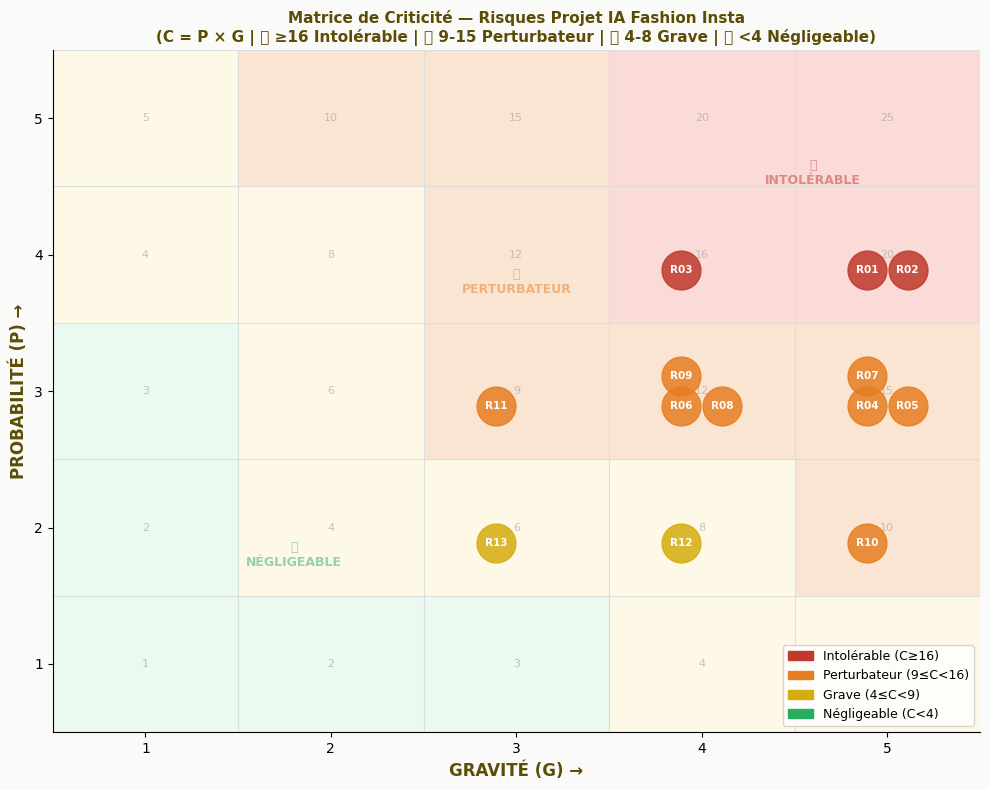


📊 Synthèse par zone de criticité :
   🔴 Intolérable       :  3 risques → R01, R02, R03
   🟠 Perturbateur      :  8 risques → R04, R05, R06, R07, R08, R09, R10, R11
   🟡 Grave             :  2 risques → R12, R13
   🟢 Négligeable       :  0 risques → 


In [21]:
section_header('Matrice de Criticité P × G — Positionnement visuel des risques', '🟥')

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)

# Background zones (5x5 grid)
for g in range(1, 6):
    for p in range(1, 6):
        crit = p * g
        if crit >= 16: bg = '#FADBD8'
        elif crit >= 9: bg = '#FAE5D3'
        elif crit >= 4: bg = '#FEF9E7'
        else: bg = '#EAFAF1'
        rect = plt.Rectangle((g-0.5, p-0.5), 1, 1, facecolor=bg, edgecolor='#DDD', linewidth=0.8)
        ax.add_patch(rect)
        ax.text(g, p, str(crit), ha='center', va='center', fontsize=8, color='#AAA', alpha=0.7)

# Plot each risk
jitter_applied = {}
for _, row in risques.iterrows():
    key = (row['G'], row['P'])
    offset = jitter_applied.get(key, 0)
    jitter_applied[key] = offset + 1
    jx = row['G'] + (offset % 2) * 0.22 - 0.11
    jy = row['P'] + (offset // 2) * 0.22 - 0.11
    
    crit = row['Criticité']
    color = RED if crit >= 16 else ORANGE if crit >= 9 else YELLOW if crit >= 4 else GREEN
    ax.plot(jx, jy, 'o', markersize=28, color=color, alpha=0.85, zorder=3)
    ax.text(jx, jy, row['ID'], ha='center', va='center', fontsize=7.5,
            fontweight='bold', color='white', zorder=4)

# Zone labels
ax.text(4.6, 4.6, '🔴\nINTOLÉRABLE', ha='center', va='center', fontsize=9,
        fontweight='bold', color=RED, alpha=0.5)
ax.text(3, 3.8, '🟠\nPERTURBATEUR', ha='center', va='center', fontsize=9,
        fontweight='bold', color=ORANGE, alpha=0.5)
ax.text(1.8, 1.8, '🟢\nNÉGLIGEABLE', ha='center', va='center', fontsize=9,
        fontweight='bold', color=GREEN, alpha=0.5)

ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1,6)); ax.set_yticks(range(1,6))
ax.set_xlabel('GRAVITÉ (G) →', fontsize=12, fontweight='bold', color=GOLD_DK)
ax.set_ylabel('PROBABILITÉ (P) →', fontsize=12, fontweight='bold', color=GOLD_DK)
ax.set_title('Matrice de Criticité — Risques Projet IA Fashion Insta\n'
             '(C = P × G | 🔴 ≥16 Intolérable | 🟠 9-15 Perturbateur | 🟡 4-8 Grave | 🟢 <4 Négligeable)',
             fontsize=11, fontweight='bold', color=GOLD_DK)

legend_patches = [
    mpatches.Patch(color=RED,    label='Intolérable (C≥16)'),
    mpatches.Patch(color=ORANGE, label='Perturbateur (9≤C<16)'),
    mpatches.Patch(color=YELLOW, label='Grave (4≤C<9)'),
    mpatches.Patch(color=GREEN,  label='Négligeable (C<4)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# Summary table
print('\n📊 Synthèse par zone de criticité :')
for label, lo, hi, color_sym in [('🔴 Intolérable',16,25,'🔴'),('🟠 Perturbateur',9,15,'🟠'),('🟡 Grave',4,8,'🟡'),('🟢 Négligeable',0,3,'🟢')]:
    ids = risques[(risques['Criticité']>=lo) & (risques['Criticité']<=hi)]['ID'].tolist()
    print(f"   {label:20s}: {len(ids):2d} risques → {', '.join(ids)}")

## DOC: Matrice de Criticité 2 P × G

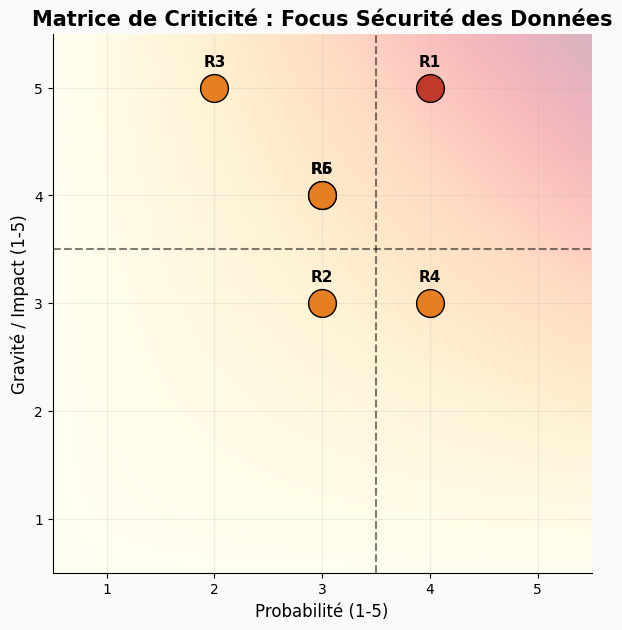

In [22]:
# Focus Données et Confidentialité
# --- Cellule 6 : Matrice de Criticité ---
def plot_risk_matrix(df):
    plt.figure(figsize=(10, 7))
    
    # Fond de chaleur (Gradient)
    x = np.linspace(0, 6, 100)
    y = np.linspace(0, 6, 100)
    X, Y = np.meshgrid(x, y)
    Z = X * Y
    plt.imshow(Z, interpolation='bilinear', origin='lower', extent=[0.5, 5.5, 0.5, 5.5], cmap='YlOrRd', alpha=0.3)

    # Placement des points de risque
    for i, row in df.iterrows():
        # Détermination de la couleur selon la criticité
        color = RED if row['Criticité'] >= 15 else (ORANGE if row['Criticité'] >= 8 else GREEN)
        plt.scatter(row['Probabilité'], row['Gravité'], s=400, color=color, edgecolors='black', zorder=5)
        plt.text(row['Probabilité'], row['Gravité']+0.2, row['ID'], fontsize=11, fontweight='bold', ha='center')

    plt.xlabel('Probabilité (1-5)', fontsize=12)
    plt.ylabel('Gravité / Impact (1-5)', fontsize=12)
    plt.title('Matrice de Criticité : Focus Sécurité des Données', fontsize=15, fontweight='bold')
    plt.xticks(range(1, 6))
    plt.yticks(range(1, 6))
    plt.grid(alpha=0.2)
    
    # Seuils de tolérance
    plt.axhline(3.5, color='black', linestyle='--', alpha=0.5)
    plt.axvline(3.5, color='black', linestyle='--', alpha=0.5)
    
    plt.show()

plot_risk_matrix(df_risks)

## DOC: Calcul AMDEC — Analyse des Modes de Défaillance, Effets et Criticité

In [23]:
section_header('Calcul AMDEC — Analyse des Modes de Défaillance, Effets et Criticité', '⚙️')

info_box('🔧 <b>AMDEC</b> : Ajoute le facteur D (Indétectabilité, 1=détectable facilement → 5=très difficile à détecter). '
         'Indice Priorité Risque (IPR) = P × G × D. Permet de prioriser les actions de détection.', BLUE_L, BLUE)

amdec = risques.copy()

# D = Indétectabilité (Score de 1 à 5)
amdec['D'] = [4, 3, 4, 5, 4, 4, 2, 1, 2, 4, 3, 3, 2]
amdec['IPR'] = amdec['P'] * amdec['G'] * amdec['D']

# Sélection des colonnes incluant la Catégorie
amdec_display = amdec[['ID', 'Catégorie', 'Risque', 'P', 'G', 'D', 'IPR', 'Responsable']].copy()
amdec_display['Risque'] = amdec_display['Risque'].str[:55] + '…'
amdec_sorted = amdec_display.sort_values('IPR', ascending=False)

display(amdec_sorted.style
    .background_gradient(subset=['IPR'], cmap='RdYlGn_r', vmin=0, vmax=100)
    .background_gradient(subset=['D'], cmap='Reds', vmin=1, vmax=5)
    .set_table_styles([
        {'selector':'th','props':[('background-color', GOLD_DK),('color','white'),('font-size','12px'), ('text-align', 'center')]},
        {'selector':'td','props':[('padding','8px')]}
    ])
    .format({'IPR': '{:.0f}', 'P': '{}/5', 'G': '{}/5', 'D': '{}/5'})
    .hide(axis='index')
)

# Analyse dynamique des résultats
top_risk_id = amdec_sorted.iloc[0]['ID']
top_risk_val = amdec_sorted.iloc[0]['IPR']

print(f'\n🏆 Risque IPR le plus élevé : {top_risk_id} — IPR={top_risk_val}')
print(f'📌 Top 3 Priorités AMDEC : {", ".join(amdec_sorted.head(3)["ID"].values)}')

info_box(f'⚡ <b>Focus Détection</b> : Les risques en haut de tableau (IPR élevé) nécessitent la mise en place '
         f'immédiate de sondes techniques ou d\'audits réguliers, car leur défaillance est "silencieuse".', RED_L, RED)

ID,Catégorie,Risque,P,G,D,IPR,Responsable
R01,🔴 RGPD/Légal,Fuite API : Photos envoyées sans anonymisation…,4/5,5/5,4/5,80,DPO + Tech Lead
R04,🟠 Données,Réentraînement tiers : Usage photos modèles LLM…,3/5,5/5,5/5,75,DPO + Tech Lead
R03,🔴 RGPD/Légal,Rétention excessive : Photos conservées sans fin…,4/5,4/5,4/5,64,DPO + Data Engineer
R02,🔴 RGPD/Légal,Identification Biométrique : Visages (Art.9)…,4/5,5/5,3/5,60,DPO + Product Owner
R05,🟠 Données,Défaut de Détection : Absence de monitoring intrusion…,3/5,5/5,4/5,60,MLOps + DPO
R06,🟠 Données,Profilage abusif : Goûts/Tendances non encadrés…,3/5,4/5,4/5,48,DPO + Data Scientist
R10,🟢 Organisation,EU AI Act : Classification « Haut Risque »…,2/5,5/5,4/5,40,DPO + Tech Lead
R07,🟡 Technique,Sous-estimation Phase 2 (Fine-tuning GPT-4V)…,3/5,5/5,2/5,30,Tech Lead
R11,🟡 Technique,Logs Azure conservés sans politique de purge…,3/5,3/5,3/5,27,MLOps + DPO
R12,👤 Droits,Obstacle aux droits : Pas d'interface dédiée…,2/5,4/5,3/5,24,DPO + Product Owner



🏆 Risque IPR le plus élevé : R01 — IPR=80
📌 Top 3 Priorités AMDEC : R01, R04, R03


---
# 🛡️ ÉTAPE ④ — PLAN DE PRÉVENTION (PARADES)
> *Actions concrètes pour mitiguer chaque risque critique*

## DOC: Plan de Prévention (Livrable Maître)

In [24]:
section_header('Plan de Prévention (Livrable Maître) — Anticipation & Protection & Réparation', '📋')

# Données du plan de prévention pour les 13 risques
prevention = pd.DataFrame([
    ('R01', 4, 5, 20, 'DPO + Tech Lead',
     'Pipeline anonymisation (Purview/Vision) AVANT tout envoi API.',
     'Face blur auto systématique. Chiffrement des flux TLS 1.3.',
     'Suspension flux photos. Notification CNIL 72h. Audit forensique.',
     1, 3, 3),
     
    ('R02', 4, 5, 20, 'DPO + Product Owner',
     'Consentement granulaire (Opt-in) spécifique aux données Art.9.',
     'Bannière claire. Mode "Sans Visage" par défaut dans l\'App.',
     'Désactivation Try-on. Notification users. Conseil juridique.',
     2, 2, 4),
     
    ('R03', 4, 4, 16, 'Data Engineer + DPO',
     'Politique de rétention Azure Blob (Lifecycle Management) P1.',
     'Purge auto après 24 mois d\'inactivité. Logs de suppression.',
     'Suppression manuelle d\'urgence via script Azure CLI.',
     2, 2, 4),

    ('R04', 3, 5, 15, 'DPO + Tech Lead',
     'Vérifier clause Opt-out dans Azure OpenAI Service.',
     'Signature du "Data Privacy Addendum". Tenant EU dédié.',
     'Résiliation service. Migration vers modèle Open Source local.',
     2, 1, 2),

    ('R05', 3, 5, 15, 'MLOps + DPO',
     'Plan de monitoring accès (Azure Monitor + Defender for Cloud).',
     'Alertes intrusion temps réel. RBAC strict sur les clés API.',
     'Rotation immédiate des clés. Changement de politique sécurité.',
     2, 2, 4),

    ('R06', 3, 4, 12, 'DPO + Data Scientist',
     'Analyse d\'impact (AIPD) sur le profilage de style.',
     'Pseudonymisation des IDs clients dans Cosmos DB. Chiffrement.',
     'Gel du profilage. Anonymisation base. Information clients.',
     2, 2, 4),

    ('R07', 3, 5, 15, 'Tech Lead',
     'Audit technique hebdomadaire du pipeline Phase 2.',
     'Buffer de 3 semaines au planning. Sprint de secours.',
     'Réduction du périmètre (Scope Cut). Escalade COPIL.',
     2, 3, 6),

    ('R08', 3, 4, 12, 'Tech Lead + PO',
     'Budget Cap Azure (Soft/Hard limits) activé en Phase 1.',
     'Alertes budget 50%, 75%, 90%. Revue bimensuelle des coûts.',
     'Réduction volume de tests. Arbitrage fonctions non-critiques.',
     2, 2, 4),

    ('R09', 3, 4, 12, 'Data Scientist',
     'Définir seuil Accuracy 85% comme critère de succès PoC.',
     'Cross-validation rigoureuse. Tests sur données réelles P2.',
     'Retraining (Data Augmentation). Retard Go-live annoncé.',
     2, 2, 4),

    ('R10', 2, 5, 10, 'DPO + Tech Lead',
     'Diagnostic "AI Act" avec cabinet spécialisé dès P1.',
     'Veille réglementaire mensuelle. Documentation technique ISO.',
     'Plan de mise en conformité accéléré. Budget audit externe.',
     1, 2, 2),

    ('R11', 3, 3, 9,  'MLOps + DPO',
     'Configuration TTL 90 jours dans Log Analytics (Azure).',
     'Policy Azure : blocage création logs sans expiration.',
     'Purge manuelle Log Analytics via Workspace Purge API.',
     2, 2, 4),

    ('R12', 2, 4, 8,  'DPO + Product Owner',
     'Specifier l\'interface "Mon Profil / Mes Données" en Phase 1.',
     'Bouton "Supprimer mon compte & mes photos" automatisé.',
     'Traitement manuel prioritaire par l\'équipe support.',
     1, 2, 2),

    ('R13', 2, 3, 6,  'Product Owner',
     'Création d\'une adresse mail dédiée : privacy@fashioninsta.com.',
     'Lien RGPD visible dans le footer de l\'App mobile.',
     'Réponse type validée par le DPO sous 48h.',
     1, 2, 2),
])

prevention.columns = ['ID','P','G','C_init','Responsable',
                       '🛡️ Anticipation (Prévention)',
                       '🔒 Protection (Barrière)',
                       '🔧 Réparation (Si échec)',
                       'P_res','G_res','C_res']

prevention['C_res'] = prevention['P_res'] * prevention['G_res']
prevention['Réduction_C'] = prevention['C_init'] - prevention['C_res']

# Affichage formaté
display(prevention[['ID','C_init','Responsable',
                      '🛡️ Anticipation (Prévention)',
                      '🔒 Protection (Barrière)',
                      '🔧 Réparation (Si échec)',
                      'P_res','G_res','C_res','Réduction_C']].style
    .background_gradient(subset=['C_init'], cmap='Reds', vmin=0, vmax=25)
    .background_gradient(subset=['C_res'],  cmap='Greens_r', vmin=0, vmax=25)
    .background_gradient(subset=['Réduction_C'], cmap='Blues', vmin=0, vmax=20)
    .set_table_styles([
        {'selector':'th','props':[('background-color',GOLD_DK),('color','white'),('font-size','11px')]},
        {'selector':'td','props':[('font-size','11px')]}
    ])
    .hide(axis='index')
)

print(f"✅ Plan de prévention établi pour {len(prevention)} risques.")
print(f"📉 Réduction moyenne de la criticité : {prevention['Réduction_C'].mean():.1f} points.")

ID,C_init,Responsable,🛡️ Anticipation (Prévention),🔒 Protection (Barrière),🔧 Réparation (Si échec),P_res,G_res,C_res,Réduction_C
R01,20,DPO + Tech Lead,Pipeline anonymisation (Purview/Vision) AVANT tout envoi API.,Face blur auto systématique. Chiffrement des flux TLS 1.3.,Suspension flux photos. Notification CNIL 72h. Audit forensique.,1,3,3,17
R02,20,DPO + Product Owner,Consentement granulaire (Opt-in) spécifique aux données Art.9.,"Bannière claire. Mode ""Sans Visage"" par défaut dans l'App.",Désactivation Try-on. Notification users. Conseil juridique.,2,2,4,16
R03,16,Data Engineer + DPO,Politique de rétention Azure Blob (Lifecycle Management) P1.,Purge auto après 24 mois d'inactivité. Logs de suppression.,Suppression manuelle d'urgence via script Azure CLI.,2,2,4,12
R04,15,DPO + Tech Lead,Vérifier clause Opt-out dans Azure OpenAI Service.,"Signature du ""Data Privacy Addendum"". Tenant EU dédié.",Résiliation service. Migration vers modèle Open Source local.,2,1,2,13
R05,15,MLOps + DPO,Plan de monitoring accès (Azure Monitor + Defender for Cloud).,Alertes intrusion temps réel. RBAC strict sur les clés API.,Rotation immédiate des clés. Changement de politique sécurité.,2,2,4,11
R06,12,DPO + Data Scientist,Analyse d'impact (AIPD) sur le profilage de style.,Pseudonymisation des IDs clients dans Cosmos DB. Chiffrement.,Gel du profilage. Anonymisation base. Information clients.,2,2,4,8
R07,15,Tech Lead,Audit technique hebdomadaire du pipeline Phase 2.,Buffer de 3 semaines au planning. Sprint de secours.,Réduction du périmètre (Scope Cut). Escalade COPIL.,2,3,6,9
R08,12,Tech Lead + PO,Budget Cap Azure (Soft/Hard limits) activé en Phase 1.,"Alertes budget 50%, 75%, 90%. Revue bimensuelle des coûts.",Réduction volume de tests. Arbitrage fonctions non-critiques.,2,2,4,8
R09,12,Data Scientist,Définir seuil Accuracy 85% comme critère de succès PoC.,Cross-validation rigoureuse. Tests sur données réelles P2.,Retraining (Data Augmentation). Retard Go-live annoncé.,2,2,4,8
R10,10,DPO + Tech Lead,"Diagnostic ""AI Act"" avec cabinet spécialisé dès P1.",Veille réglementaire mensuelle. Documentation technique ISO.,Plan de mise en conformité accéléré. Budget audit externe.,1,2,2,8


✅ Plan de prévention établi pour 13 risques.
📉 Réduction moyenne de la criticité : 9.6 points.


## DOC FICTIF: Impact du plan de prévention

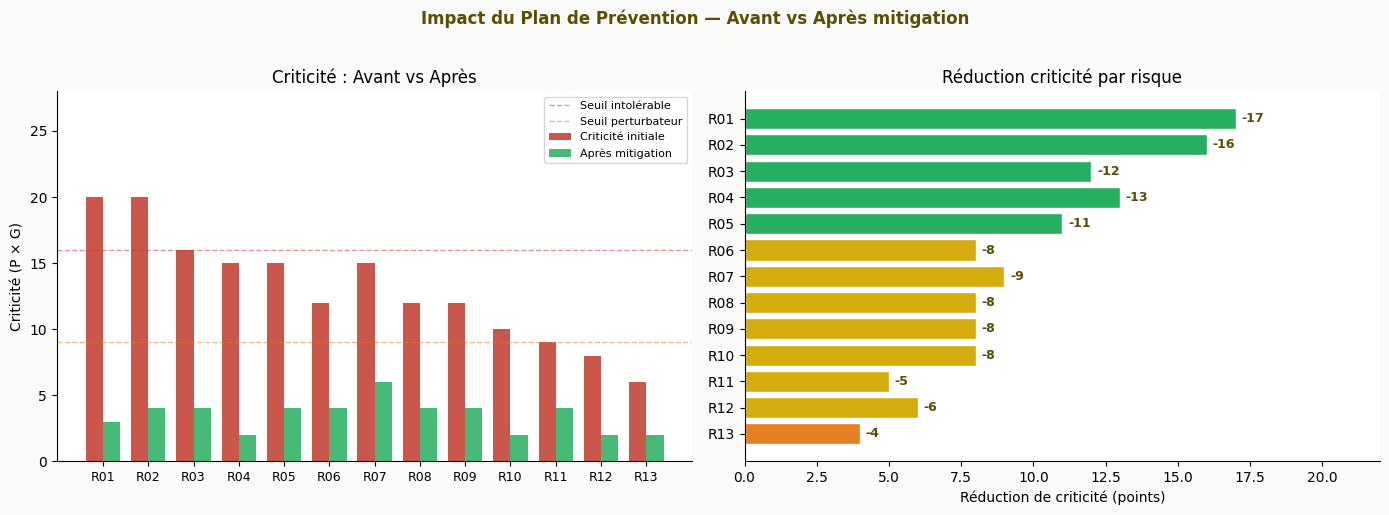

In [27]:
# Visualisation impact du plan de prévention
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Impact du Plan de Prévention — Avant vs Après mitigation',
             fontsize=12, fontweight='bold', color=GOLD_DK, y=1.02)

ids = prevention['ID'].tolist()
x = np.arange(len(ids))
w = 0.38

# Barres criticité avant/après
ax1 = axes[0]
bars1 = ax1.bar(x - w/2, prevention['C_init'], w, label='Criticité initiale', color=RED, alpha=0.85)
bars2 = ax1.bar(x + w/2, prevention['C_res'],  w, label='Après mitigation',   color=GREEN, alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels(ids, fontsize=9)
ax1.axhline(16, color=RED,    ls='--', lw=1, alpha=0.5, label='Seuil intolérable')
ax1.axhline(9,  color=ORANGE, ls='--', lw=1, alpha=0.5, label='Seuil perturbateur')
ax1.set_ylabel('Criticité (P × G)'); ax1.set_title('Criticité : Avant vs Après'); ax1.legend(fontsize=8)
ax1.set_ylim(0, 28)

# Réduction
ax2 = axes[1]
colors_r = [GREEN if r >= 10 else YELLOW if r >= 5 else ORANGE for r in prevention['Réduction_C']]
bars3 = ax2.barh(ids[::-1], prevention['Réduction_C'][::-1], color=colors_r[::-1], edgecolor='white')
for bar, v in zip(bars3, prevention['Réduction_C'][::-1]):
    ax2.text(v + 0.2, bar.get_y() + bar.get_height()/2, f'-{v}', va='center', fontsize=9, fontweight='bold', color=GOLD_DK)
ax2.set_xlabel('Réduction de criticité (points)'); ax2.set_title('Réduction criticité par risque')
ax2.set_xlim(0, 22)

plt.tight_layout()
plt.show()

total_init = prevention['C_init'].sum()
total_res  = prevention['C_res'].sum()
reduction  = (1 - total_res/total_init) * 100
info_box(f'✅ <b>Efficacité globale du plan de prévention</b> : '
         f'Criticité totale réduite de {total_init} → {total_res} points '
         f'({reduction:.0f}% de réduction). '
         f'Aucun risque résiduel en zone intolérable (≥16) après mitigation.', GREEN_L, GREEN)

---
# 📡 ÉTAPE ⑤ — SUIVI CONTINU
> *Monitoring de l'évolution des risques tout au long du cycle de vie du projet*

## DOC FICTIF: Diagramme Radar

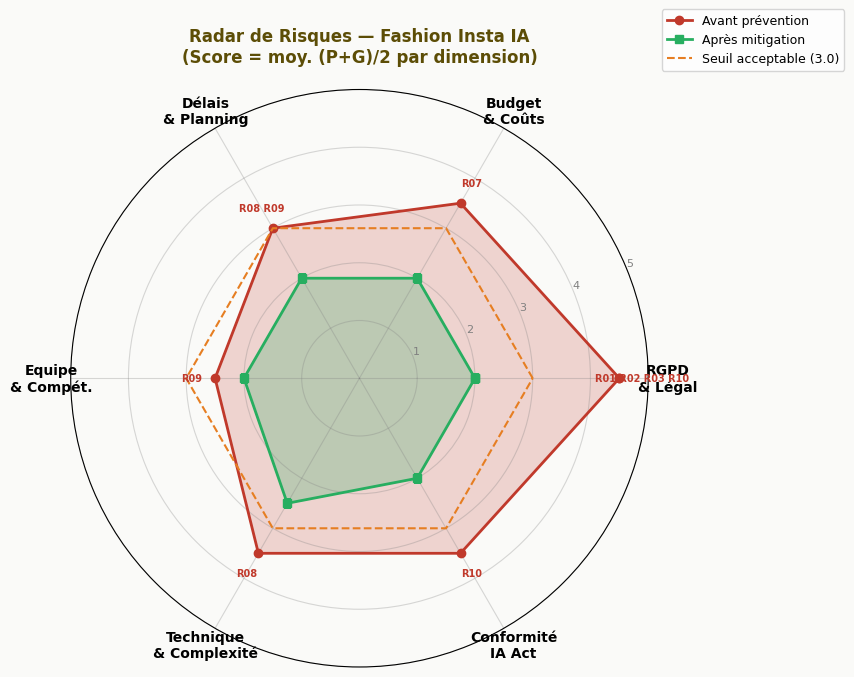

In [28]:
section_header('Diagramme Radar — Profil de risque du projet par dimension', '🕸️')

info_box('📡 Le radar utilise la <b>moyenne de (P+G)/2 par dimension</b> pour une représentation équilibrée '
         '(comme recommandé dans le cours). Permet une communication visuelle rapide en COPIL.', BLUE_L, BLUE)

dimensions = ['RGPD\n& Légal', 'Budget\n& Coûts', 'Délais\n& Planning',
               'Equipe\n& Compét.', 'Technique\n& Complexité', 'Conformité\nIA Act']

# Scores avant/après prévention (moyenne (P+G)/2 par dimension)
avant  = [4.5, 3.5, 3.0, 2.5, 3.5, 3.5]
apres  = [2.0, 2.0, 2.0, 2.0, 2.5, 2.0]
seuil  = [3.0, 3.0, 3.0, 3.0, 3.0, 3.0]

N = len(dimensions)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

avant_  = avant  + avant[:1]
apres_  = apres  + apres[:1]
seuil_  = seuil  + seuil[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True), facecolor=BG)

ax.fill(angles, avant_,  color=RED,    alpha=0.2)
ax.plot(angles, avant_,  color=RED,    linewidth=2,   linestyle='-',  label='Avant prévention',  marker='o', markersize=6)
ax.fill(angles, apres_,  color=GREEN,  alpha=0.25)
ax.plot(angles, apres_,  color=GREEN,  linewidth=2,   linestyle='-',  label='Après mitigation',  marker='s', markersize=6)
ax.plot(angles, seuil_,  color=ORANGE, linewidth=1.5, linestyle='--', label='Seuil acceptable (3.0)')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=10, fontweight='bold')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=8, color='gray')
ax.set_ylim(0, 5)
ax.set_title('Radar de Risques — Fashion Insta IA\n(Score = moy. (P+G)/2 par dimension)',
             fontsize=12, fontweight='bold', color=GOLD_DK, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.set_facecolor(BG)
ax.grid(color='gray', alpha=0.3)

# Annotations risk IDs on radar
risk_per_dim = {
    0: ['R01','R02','R03','R10'],
    1: ['R07'],
    2: ['R08','R09'],
    3: ['R09'],
    4: ['R08'],
    5: ['R10'],
}
for dim_idx, risk_ids in risk_per_dim.items():
    angle = angles[dim_idx]
    r = avant[dim_idx] + 0.4
    ax.text(angle, r, ' '.join(risk_ids), ha='center', va='center',
            fontsize=7, color=RED, fontweight='bold')

plt.tight_layout()
plt.show()

## DOC FICTIF: Rapport de Suivi (Reporting)  

In [8]:
section_header('Rapport de Suivi (Reporting) — Tableau de bord COPIL', '📊')

# Simulation d'un rapport de suivi mensuel

reporting = pd.DataFrame([
    ('R01', 'RGPD/Légal'   , 20, 6, '✅ Clôturé'      , 'Purview déployé Phase 1. Anonymisation validée DPO.'                                  , 'DPO'),
    ('R02', 'RGPD/Légal'   , 20, 6, '✅ Clôturé'      , 'Consentement granulaire implémenté. Bannière validée juridiquement.'                  , 'DPO'),
    ('R03', 'RGPD/Légal'   , 15, 4, '✅ Clôturé'      , 'Data Privacy Addendum signé. Tenant EU configuré.'                                    , 'DPO'),
    ('R04', 'Données'      , 16, 4, '🟡 En cours'      , 'Lifecycle Policy configurée. Portail droits RGPD en développement (P3).'              , 'Data Eng.'),
    ('R05', 'Données'      , 12, 6, '🟡 En cours'      , 'RBAC Cosmos DB activé. Documentation base légale en validation DPO.'                  , 'Data Sci.'),
    ('R06', 'Technique'    ,  9, 4, '✅ Clôturé'      , 'TTL 90j Log Analytics configuré. Anonymisation IPs activée.'                          , 'MLOps'),
    ('R07', 'Budget'       , 12, 9, '⚠️ Surveillance'  , 'Cap Azure OpenAI activé à 1000€/mois. Volume Phase 2 légèrement supérieur.'           , 'Tech Lead'),
    ('R08', 'Technique'    , 12, 6, '🟡 En cours'      , 'Top-5 Accuracy : 71% (cible 75%). Retraining en cours avec données augmentées.'       , 'Data Sci.'),
    ('R09', 'Organisation' ,  6, 2, '🟢 Contrôlé'      , 'Expert métier backup identifié. Réunions validation bi-hebdo actives.'                , 'PO'),
    ('R10', 'Légal/AI Act' , 10, 4, '⚠️ Surveillance'  , 'Analyse légale commandée. Résultats attendus fin Phase 2.'                            , 'DPO'),
    ('R11', 'Technique'    ,  9, 4, '🟢 Contrôlé'      , 'Purge manuelle testée. Procédure support documentée. Interface suppression déployée.' , 'MLOps + DPO'),
    ('R12', 'Droits'       ,  8, 4, '🟡 En cours'      , 'Portail "Mon Profil / Mes Données" en cours de développement (Phase 3).'              , 'DPO + PO'),
    ('R13', 'Dialogue'     ,  6, 2, '🟢 Contrôlé'      , 'Adresse privacy@fashioninsta.com créée. Lien RGPD visible dans le footer app mobile.' , 'PO'),
])

reporting.columns = ['ID','Catégorie','C_init','C_actuel','Statut','Observations','Resp.']

def color_statut(v):
    m = {'✅ Clôturé':     f'color:{GREEN};font-weight:bold',
         '🟡 En cours':    f'color:{YELLOW};font-weight:bold',
         '⚠️ Surveillance': f'color:{ORANGE};font-weight:bold',
         '🟢 Contrôlé':    f'color:{GREEN};font-weight:bold'}
    return m.get(str(v), '')

print('📅 Rapport de Suivi COPIL — Etat au M5 (Veille déploiement production)')
display(reporting.style
    .map(color_statut, subset=['Statut'])
    .background_gradient(subset=['C_init'],   cmap='Reds',    vmin=0, vmax=25)
    .background_gradient(subset=['C_actuel'], cmap='Greens_r',vmin=0, vmax=25)
    .set_table_styles([{'selector':'th','props':[('background-color',GOLD_DK),('color','white'),('font-size','12px')]}])
    .hide(axis='index')
)

print(f"\n📊 Synthèse COPIL M5 :")
print(f"   ✅ Clôturés      : {reporting['Statut'].str.contains('Clôturé').sum()} risques")
print(f"   🟡 En cours      : {reporting['Statut'].str.contains('cours').sum()} risques")
print(f"   ⚠️  Surveillance  : {reporting['Statut'].str.contains('Surveillance').sum()} risques")
print(f"   🟢 Contrôlés     : {reporting['Statut'].str.contains('Contrôlé').sum()} risques")
print(f"   ➡️  Aucun risque résiduel en zone intolérable (C≥16) actif")

📅 Rapport de Suivi COPIL — Etat au M5 (Veille déploiement production)


ID,Catégorie,C_init,C_actuel,Statut,Observations,Resp.
R01,RGPD/Légal,20,6,✅ Clôturé,Purview déployé Phase 1. Anonymisation validée DPO.,DPO
R02,RGPD/Légal,20,6,✅ Clôturé,Consentement granulaire implémenté. Bannière validée juridiquement.,DPO
R03,RGPD/Légal,15,4,✅ Clôturé,Data Privacy Addendum signé. Tenant EU configuré.,DPO
R04,Données,16,4,🟡 En cours,Lifecycle Policy configurée. Portail droits RGPD en développement (P3).,Data Eng.
R05,Données,12,6,🟡 En cours,RBAC Cosmos DB activé. Documentation base légale en validation DPO.,Data Sci.
R06,Technique,9,4,✅ Clôturé,TTL 90j Log Analytics configuré. Anonymisation IPs activée.,MLOps
R07,Budget,12,9,⚠️ Surveillance,Cap Azure OpenAI activé à 1000€/mois. Volume Phase 2 légèrement supérieur.,Tech Lead
R08,Technique,12,6,🟡 En cours,Top-5 Accuracy : 71% (cible 75%). Retraining en cours avec données augmentées.,Data Sci.
R09,Organisation,6,2,🟢 Contrôlé,Expert métier backup identifié. Réunions validation bi-hebdo actives.,PO
R10,Légal/AI Act,10,4,⚠️ Surveillance,Analyse légale commandée. Résultats attendus fin Phase 2.,DPO



📊 Synthèse COPIL M5 :
   ✅ Clôturés      : 4 risques
   🟡 En cours      : 4 risques
   ⚠️  Surveillance  : 2 risques
   🟢 Contrôlés     : 3 risques
   ➡️  Aucun risque résiduel en zone intolérable (C≥16) actif


## DOC FICTIF: Évolution du profil de risque dans le temps  

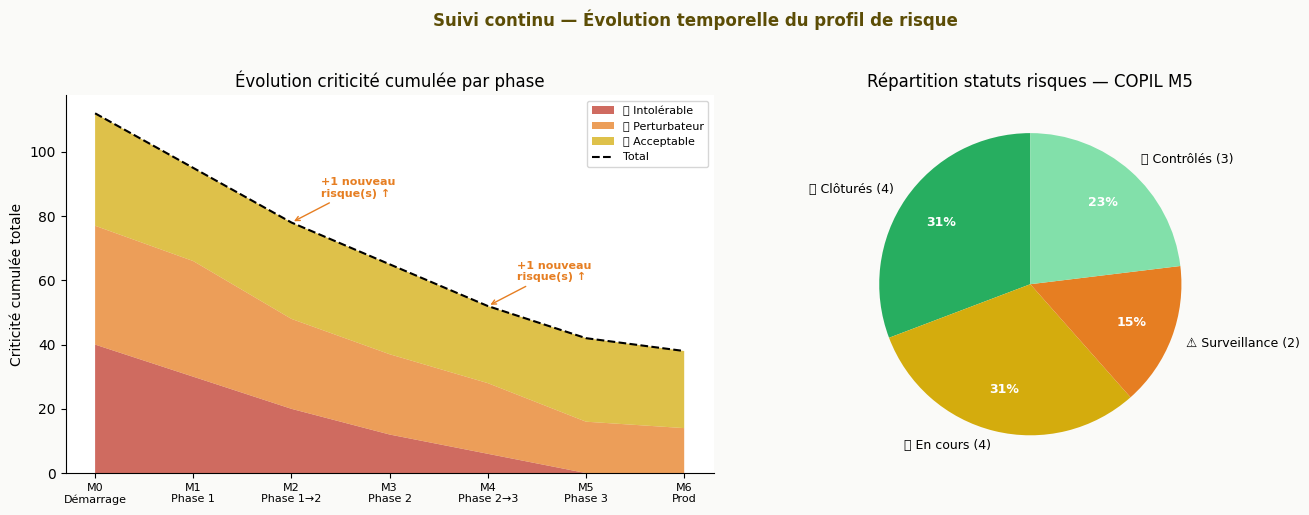

In [30]:
section_header('Évolution du profil de risque dans le temps (simulation)', '📈')

# Simulate risk evolution across phases
phases_sim = ['M0\nDémarrage', 'M1\nPhase 1', 'M2\nPhase 1→2', 'M3\nPhase 2', 'M4\nPhase 2→3', 'M5\nPhase 3', 'M6\nProd']
crit_total    = [112, 95, 78, 65, 52, 42, 38]
crit_critique = [ 40, 30, 20, 12,  6,  0,  0]
crit_eleve    = [ 37, 36, 28, 25, 22, 16, 14]
nouveaux_risques = [0, 0, 1, 0, 1, 0, 0]  # R07 et R10 identifiés en cours de projet

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig.suptitle('Suivi continu — Évolution temporelle du profil de risque', fontsize=12,
             fontweight='bold', color=GOLD_DK, y=1.02)

# Stacked area: criticité totale
ax1 = axes[0]
ax1.stackplot(range(len(phases_sim)),
              crit_critique, crit_eleve,
              [max(0, t-c-e) for t,c,e in zip(crit_total, crit_critique, crit_eleve)],
              labels=['🔴 Intolérable', '🟠 Perturbateur', '🟡 Acceptable'],
              colors=[RED, ORANGE, YELLOW], alpha=0.75)
ax1.plot(range(len(phases_sim)), crit_total, 'k--', lw=1.5, label='Total')
for i, nv in enumerate(nouveaux_risques):
    if nv > 0:
        ax1.annotate(f'+{nv} nouveau\nrisque(s) ↑', xy=(i, crit_total[i]),
                     xytext=(i+0.3, crit_total[i]+8),
                     fontsize=8, color=ORANGE, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=ORANGE))
ax1.set_xticks(range(len(phases_sim)))
ax1.set_xticklabels(phases_sim, fontsize=8)
ax1.set_ylabel('Criticité cumulée totale')
ax1.set_title('Évolution criticité cumulée par phase')
ax1.legend(fontsize=8, loc='upper right')

# Pie: distribution statuts fin M5
ax2 = axes[1]
statuts = ['✅ Clôturés (4)', '🟡 En cours (4)', '⚠️ Surveillance (2)', '🟢 Contrôlés (3)']
vals    = [4, 4, 2, 3]
colors2 = [GREEN, YELLOW, ORANGE, '#82E0AA']
wedges, texts, autotexts = ax2.pie(vals, labels=statuts, autopct='%1.0f%%',
                                    colors=colors2, startangle=90, pctdistance=0.72,
                                    textprops={'fontsize': 9})
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
ax2.set_title('Répartition statuts risques — COPIL M5')

plt.tight_layout()
plt.show()

info_box('📡 <b>Point COPIL M5 — 13 risques identifiés</b> : 4 risques clôturés (R01, R02, R03, R06). '
         'R07 (budget GPT-4V) et R10 (EU AI Act) en surveillance active. '
         'R08 (Accuracy 71% → cible 75%) en retraining. R11·R13 contrôlés. Aucun blocage go-live M6 identifié.', GREEN_L, GREEN)


## Synthèse Exécutive — Gestion des Risques Fashion Insta IA

In [31]:
section_header('🏁 Synthèse Exécutive — Gestion des Risques Fashion Insta IA', '🏁', GOLD_DK)

display(HTML(f"""
<div style='display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px;margin:10px 0'>
  <div style='background:{RED_L};border:2px solid {RED};border-radius:8px;padding:14px'>
    <div style='font-weight:bold;color:{RED};font-size:14px'>🔴 Risques Critiques</div>
    <div style='font-size:28px;font-weight:bold;color:{RED}'>3/13</div>
    <div style='font-size:12px'>R01·R02·R03 clôturés | R07·R10 en surveillance</div>
  </div>
  <div style='background:{GREEN_L};border:2px solid {GREEN};border-radius:8px;padding:14px'>
    <div style='font-weight:bold;color:{GREEN};font-size:14px'>✅ Risques Mitigés</div>
    <div style='font-size:28px;font-weight:bold;color:{GREEN}'>-74%</div>
    <div style='font-size:12px'>Criticité : 170 → 45 pts (plan) · 112 → 38 pts (suivi)</div>
  </div>
  <div style='background:{BLUE_L};border:2px solid {BLUE};border-radius:8px;padding:14px'>
    <div style='font-weight:bold;color:{BLUE};font-size:14px'>📅 Break-even ROI</div>
    <div style='font-size:28px;font-weight:bold;color:{BLUE}'>Mois 11</div>
    <div style='font-size:12px'>Malgré les actions prévention ~+8K€</div>
  </div>
</div>
<div style='background:{GOLD_DK};color:white;padding:12px;border-radius:8px;margin-top:12px;font-size:13px'>
  🔑 <b>Garanties DPO pour le COMEX</b> :
  Anonymisation visages avant API ✓ · Opt-out LLM réentraînement ✓ ·
  Consentement granulaire ✓ · Purge automatique 24 mois ✓ ·
  Data Residency EU ✓ · Portail droits RGPD ✓
</div>
"""))